# 06 - Simulación del Seguro Indexado

Este notebook evalúa el desempeño técnico-financiero del seguro construido a partir del índice de riesgo climático.

**Entradas principales**

- `data/outputs/indice_riesgo_climatico_2007-2024.csv`
- `data/model/parametros_seguro.csv`
- `data/model/precios_cafe_anual_2007-2027.csv`

**Salidas principales**

- `data/outputs/resultado_anual_seguro.csv`
- `data/outputs/resultado_cluster_seguro.csv`
- `data/outputs/resultado_riesgo_seguro.csv`
- `data/outputs/simulacion_montecarlo.csv`
- `data/outputs/resumen_portafolio_seguro.csv`

El objetivo es evaluar primas, indemnizaciones, resultado técnico, loss ratio y riesgo financiero del portafolio.


## 1. Librerías

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Rutas y parámetros

In [2]:
# ============================================================
# RUTAS ROBUSTAS DEL PROYECTO
# ============================================================

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

PATH_MODEL = PROJECT_ROOT / "data" / "model"
PATH_OUTPUTS = PROJECT_ROOT / "data" / "outputs"

PATH_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Entradas
INPUT_INDICE = PATH_OUTPUTS / "indice_riesgo_climatico_2007-2024.csv"
INPUT_PARAMETROS = PATH_MODEL / "parametros_seguro.csv"
INPUT_PRECIOS = PATH_MODEL / "precios_cafe_anual_2007-2027.csv"

# Salidas
OUTPUT_RESUMEN_PORTAFOLIO = PATH_OUTPUTS / "resumen_portafolio_seguro.csv"
OUTPUT_RESULTADO_ANUAL = PATH_OUTPUTS / "resultado_anual_seguro.csv"
OUTPUT_RESULTADO_CLUSTER = PATH_OUTPUTS / "resultado_cluster_seguro.csv"
OUTPUT_RESULTADO_RIESGO = PATH_OUTPUTS / "resultado_riesgo_seguro.csv"
OUTPUT_MONTECARLO = PATH_OUTPUTS / "simulacion_montecarlo.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_INDICE:", INPUT_INDICE)
print("INPUT_PARAMETROS:", INPUT_PARAMETROS)
print("INPUT_PRECIOS:", INPUT_PRECIOS)


PROJECT_ROOT: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos
INPUT_INDICE: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/indice_riesgo_climatico_2007-2024.csv
INPUT_PARAMETROS: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/model/parametros_seguro.csv
INPUT_PRECIOS: /home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/model/precios_cafe_anual_2007-2027.csv


In [3]:
# ============================================================
# PARÁMETROS DE SIMULACIÓN
# ============================================================

N_SIM = 5000
N_POLIZAS = 100
RANDOM_STATE = 42

# Si no se encuentra columna de área sembrada, se simula por hectárea.
AREA_DEFAULT_HA = 1.0


## 3. Carga de insumos

In [4]:
df = pd.read_csv(INPUT_INDICE)
parametros = pd.read_csv(INPUT_PARAMETROS)
precios = pd.read_csv(INPUT_PRECIOS)

params = parametros.iloc[0].to_dict()

print("Filas índice:", len(df))
print("Columnas índice:", df.columns.tolist()[:10], "...")
print("Parámetros cargados:")
print(parametros.T)


Filas índice: 450
Columnas índice: ['municipio', 'date', 'anio', 'Área sembrada (ha)', 'Rendimiento (t/ha)', 'produccion_t', 'precip_mm_sum', 'precip_mm_mean', 'precip_mm_std', 'precip_mm_min'] ...
Parámetros cargados:
                                                                            0
version_modelo                                        v1_indice_cluster_ridge
fecha_calibracion                                                  2026-05-16
target                                                     Rendimiento (t/ha)
n_observaciones                                                           450
n_municipios                                                               25
n_clusters                                                                  4
n_variables_indice                                                         12
variables_indice            ndvi_min_m12;et_potencial_mm_std;temp_mean_z_m...
loss_quantile                                                             0.3
u

In [5]:
# Validaciones mínimas
cols_necesarias = [
    "municipio", "anio", "cluster",
    "Rendimiento (t/ha)", "riesgo",
    "payout", "evento_perdida_global"
]

faltantes = [c for c in cols_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias en el índice: {faltantes}")

# Nombre esperado de precio anual
if "precio_referencia_USD_ton" in precios.columns:
    col_precio = "precio_referencia_USD_ton"
elif "PM30_prom_USD_ton" in precios.columns:
    col_precio = "PM30_prom_USD_ton"
else:
    raise ValueError("No se encontró columna de precio anual compatible.")

print("Columna de precio usada:", col_precio)


Columna de precio usada: PM30_prom_USD_ton


## 4. Preparación económica del portafolio

El índice climático produce un `payout` relativo entre 0 y 1.

Para expresarlo económicamente se calcula un monto asegurado aproximado:

```text
monto_asegurado = rendimiento_promedio_municipal × precio_café × área
```

Este supuesto permite evaluar el seguro en términos monetarios relativos.  
En la API final, el usuario podrá ingresar su área cultivada y el sistema recalculará el monto asegurado individual.


In [6]:
# Unir precio anual
precios_aux = precios[["anio", col_precio]].copy()
precios_aux = precios_aux.rename(columns={col_precio: "precio_USD_ton"})

df = df.merge(precios_aux, on="anio", how="left")

if df["precio_USD_ton"].isna().sum() > 0:
    raise ValueError("Existen registros sin precio anual asignado.")

# Área
if "Área sembrada (ha)" in df.columns:
    df["area_ha_simulada"] = df["Área sembrada (ha)"].fillna(AREA_DEFAULT_HA)
else:
    df["area_ha_simulada"] = AREA_DEFAULT_HA

# Rendimiento esperado base por municipio
df["rendimiento_esperado_mun"] = (
    df.groupby("municipio")["Rendimiento (t/ha)"].transform("mean")
)

# Monto asegurado
df["monto_asegurado"] = (
    df["rendimiento_esperado_mun"] *
    df["precio_USD_ton"] *
    df["area_ha_simulada"]
)

# Tasas desde parámetros
prima_pura_rate = float(params["prima_pura"])
prima_comercial_rate = float(params["prima_comercial"])

df["prima_pura"] = prima_pura_rate * df["monto_asegurado"]
df["prima_comercial"] = prima_comercial_rate * df["monto_asegurado"]
df["indemnizacion"] = df["payout"] * df["monto_asegurado"]

df["resultado_puro"] = df["prima_pura"] - df["indemnizacion"]
df["resultado_comercial"] = df["prima_comercial"] - df["indemnizacion"]

df[[
    "municipio", "anio", "cluster", "riesgo",
    "Rendimiento (t/ha)", "precio_USD_ton",
    "area_ha_simulada", "monto_asegurado",
    "prima_comercial", "indemnizacion",
    "resultado_comercial"
]].head()


,municipio,anio,cluster,riesgo,Rendimiento (t/ha),precio_USD_ton,area_ha_simulada,monto_asegurado,prima_comercial,indemnizacion,resultado_comercial
0,Aguadas,2007,1,Alto,0.97,2581.22,4626.0,1.267707e+07,4.006673e+06,1.217873e+03,4.005455e+06
1,Anserma,2007,2,Alto,1.30,2581.22,7125.0,2.122139e+07,6.707164e+06,4.472379e+06,2.234785e+06
2,Aranzazu,2007,1,Alto,1.01,2581.22,2597.0,7.113082e+06,2.248138e+06,2.828591e+06,-5.804534e+05
3,Belalcázar,2007,2,Bajo,1.20,2581.22,3734.0,1.102512e+07,3.484562e+06,0.000000e+00,3.484562e+06
4,Chinchiná,2007,2,Bajo,1.63,2581.22,5632.0,1.848677e+07,5.842867e+06,0.000000e+00,5.842867e+06


## 5. Resumen general del portafolio

In [7]:
resumen_portafolio = pd.DataFrame([{
    "n_observaciones": len(df),
    "n_municipios": df["municipio"].nunique(),
    "anio_min": df["anio"].min(),
    "anio_max": df["anio"].max(),
    "prima_pura_total": df["prima_pura"].sum(),
    "prima_comercial_total": df["prima_comercial"].sum(),
    "indemnizacion_total": df["indemnizacion"].sum(),
    "resultado_puro_total": df["resultado_puro"].sum(),
    "resultado_comercial_total": df["resultado_comercial"].sum(),
    "loss_ratio_puro": df["indemnizacion"].sum() / df["prima_pura"].sum(),
    "loss_ratio_comercial": df["indemnizacion"].sum() / df["prima_comercial"].sum(),
    "payout_promedio": df["payout"].mean(),
    "tasa_evento_perdida": df["evento_perdida_global"].mean()
}])

resumen_portafolio


,n_observaciones,n_municipios,anio_min,anio_max,prima_pura_total,prima_comercial_total,indemnizacion_total,resultado_puro_total,resultado_comercial_total,loss_ratio_puro,loss_ratio_comercial,payout_promedio,tasa_evento_perdida
0,450,25,2007,2024,1.383436e+09,1.798467e+09,1.320206e+09,6.322980e+07,4.782606e+08,0.954295,0.734073,0.243121,0.337778


## 6. Resultado anual del seguro

In [8]:
resultado_anual = (
    df
    .groupby("anio")
    .agg(
        n=("anio", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean"),
        monto_asegurado_total=("monto_asegurado", "sum")
    )
    .reset_index()
)

resultado_anual["loss_ratio"] = (
    resultado_anual["indemnizacion_total"] /
    resultado_anual["prima_total"]
)

resultado_anual


,anio,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,monto_asegurado_total,loss_ratio
0,2007,25,1.011642e+08,2.985941e+07,7.130478e+07,0.097624,0.28,3.200824e+08,0.295158
1,2008,25,1.054110e+08,5.918568e+07,4.622530e+07,0.217791,0.40,3.335191e+08,0.561475
2,2009,25,1.008513e+08,6.753932e+07,3.331203e+07,0.211031,0.56,3.190925e+08,0.669692
3,2010,25,1.198707e+08,3.735439e+07,8.251634e+07,0.178898,0.40,3.792696e+08,0.311622
4,2011,25,2.009221e+08,1.592578e+08,4.166430e+07,0.251804,0.40,6.357153e+08,0.792635
5,2012,25,1.251560e+08,1.827409e+08,-5.758484e+07,0.473774,0.88,3.959923e+08,1.460104
6,2013,25,9.121716e+07,9.975115e+07,-8.533992e+06,0.336170,0.76,2.886101e+08,1.093557
7,2014,25,1.205189e+08,1.423984e+08,-2.187943e+07,0.378080,0.16,3.813206e+08,1.181544
8,2015,25,9.436560e+07,7.094229e+07,2.342331e+07,0.262556,0.08,2.985717e+08,0.751781
9,2016,25,9.045027e+07,1.470553e+07,7.574474e+07,0.085199,0.08,2.861836e+08,0.162581


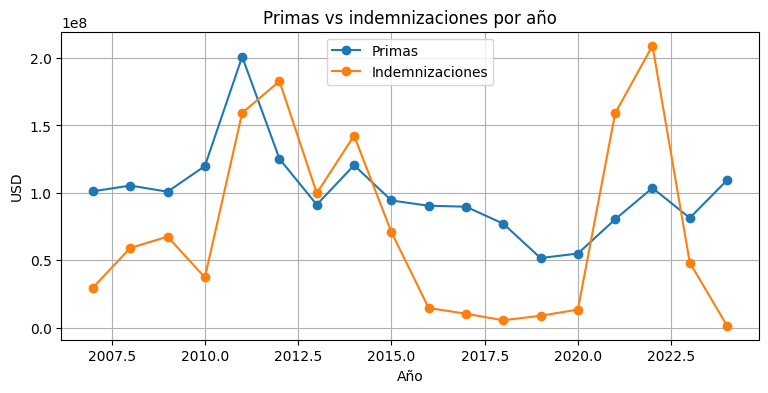

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(resultado_anual["anio"], resultado_anual["prima_total"], marker="o", label="Primas")
plt.plot(resultado_anual["anio"], resultado_anual["indemnizacion_total"], marker="o", label="Indemnizaciones")
plt.xlabel("Año")
plt.ylabel("USD")
plt.title("Primas vs indemnizaciones por año")
plt.legend()
plt.grid(True)
plt.show()


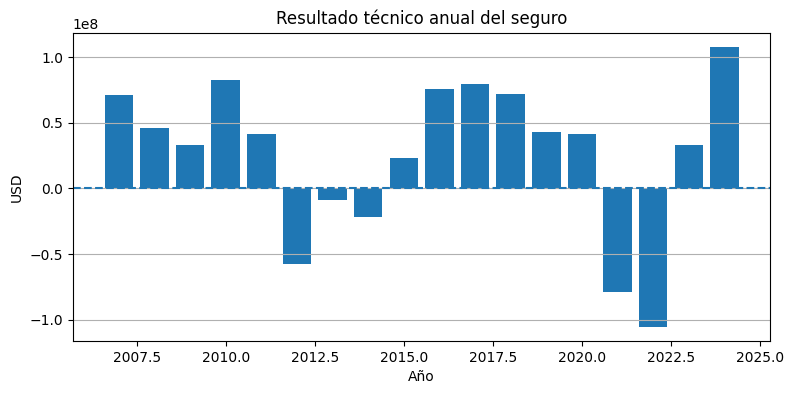

In [10]:
plt.figure(figsize=(9, 4))
plt.bar(resultado_anual["anio"], resultado_anual["resultado_total"])
plt.axhline(0, linestyle="--")
plt.xlabel("Año")
plt.ylabel("USD")
plt.title("Resultado técnico anual del seguro")
plt.grid(axis="y")
plt.show()


## 7. Resultado por clúster

In [11]:
resultado_cluster = (
    df
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean"),
        monto_asegurado_total=("monto_asegurado", "sum")
    )
    .reset_index()
)

resultado_cluster["loss_ratio"] = (
    resultado_cluster["indemnizacion_total"] /
    resultado_cluster["prima_total"]
)

resultado_cluster


,cluster,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,monto_asegurado_total,loss_ratio
0,0,36,6.131162e+07,3.533149e+07,2.598013e+07,0.233895,0.500000,1.939893e+08,0.576261
1,1,162,7.380312e+08,5.333357e+08,2.046955e+08,0.231944,0.345679,2.335122e+09,0.722647
2,2,198,8.363477e+08,5.688379e+08,2.675098e+08,0.253543,0.262626,2.646195e+09,0.680145
3,3,54,1.627763e+08,1.827011e+08,-1.992482e+07,0.244584,0.481481,5.150224e+08,1.122406


## 8. Resultado por nivel de riesgo

In [12]:
resultado_riesgo = (
    df
    .groupby("riesgo")
    .agg(
        n=("riesgo", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean"),
        rendimiento_promedio=("Rendimiento (t/ha)", "mean"),
        monto_asegurado_total=("monto_asegurado", "sum")
    )
    .reset_index()
)

resultado_riesgo["loss_ratio"] = (
    resultado_riesgo["indemnizacion_total"] /
    resultado_riesgo["prima_total"]
)

resultado_riesgo


,riesgo,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,rendimiento_promedio,monto_asegurado_total,loss_ratio
0,Alto,274,1.060544e+09,1.320206e+09,-2.596623e+08,0.399286,0.456204,1.064635,3.355549e+09,1.244839
1,Bajo,135,5.795647e+08,0.000000e+00,5.795647e+08,0.000000,0.162963,1.314519,1.833736e+09,0.000000
2,Medio,41,1.583582e+08,0.000000e+00,1.583582e+08,0.000000,0.121951,1.203659,5.010436e+08,0.000000


## 9. Simulación Monte Carlo

Se realiza remuestreo histórico del portafolio para evaluar estabilidad financiera.

Cada simulación toma `N_POLIZAS` observaciones con reemplazo.


In [13]:
rng = np.random.default_rng(RANDOM_STATE)
simulaciones = []

for i in range(N_SIM):

    muestra = df.sample(
        n=N_POLIZAS,
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    )

    prima_total = muestra["prima_comercial"].sum()
    indemnizacion_total = muestra["indemnizacion"].sum()
    resultado_total = prima_total - indemnizacion_total
    loss_ratio = indemnizacion_total / prima_total if prima_total > 0 else np.nan

    simulaciones.append({
        "sim": i,
        "prima_total": prima_total,
        "indemnizacion_total": indemnizacion_total,
        "resultado_total": resultado_total,
        "loss_ratio": loss_ratio
    })

df_sim = pd.DataFrame(simulaciones)

df_sim.describe()


,sim,prima_total,indemnizacion_total,resultado_total,loss_ratio
count,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000
mean,2499.500000,4.000156e+08,2.931013e+08,1.069143e+08,0.733571
std,1443.520003,2.863083e+07,4.856738e+07,4.740960e+07,0.114867
min,0.000000,3.057362e+08,1.366151e+08,-9.346558e+07,0.373897
25%,1249.750000,3.806244e+08,2.587360e+08,7.523099e+07,0.654353
50%,2499.500000,3.995879e+08,2.911735e+08,1.072705e+08,0.730401
75%,3749.250000,4.186806e+08,3.243852e+08,1.393352e+08,0.810119
max,4999.000000,5.021884e+08,4.809037e+08,2.603652e+08,1.247011


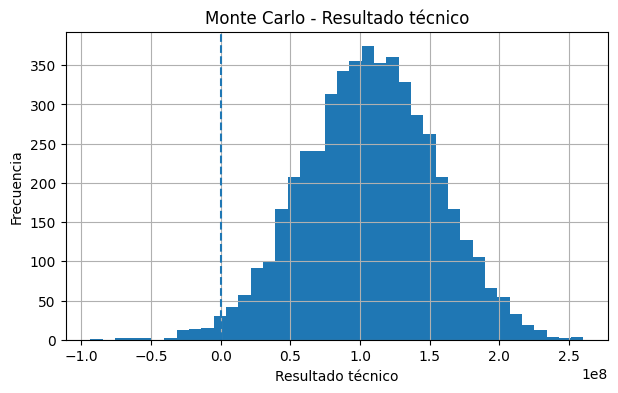

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(df_sim["resultado_total"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Resultado técnico")
plt.ylabel("Frecuencia")
plt.title("Monte Carlo - Resultado técnico")
plt.grid(True)
plt.show()


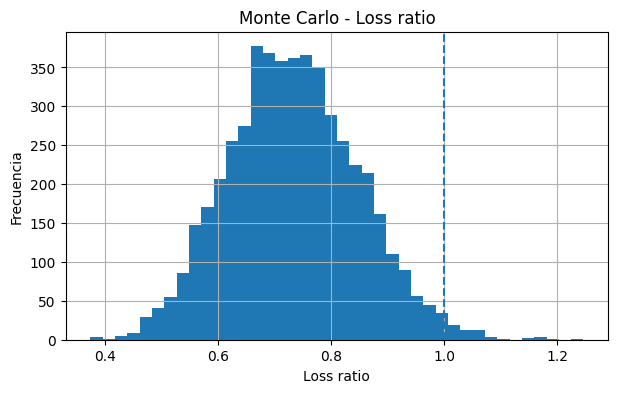

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(df_sim["loss_ratio"], bins=40)
plt.axvline(1, linestyle="--")
plt.xlabel("Loss ratio")
plt.ylabel("Frecuencia")
plt.title("Monte Carlo - Loss ratio")
plt.grid(True)
plt.show()


## 10. Métricas de riesgo financiero

In [16]:
metricas_financieras = pd.DataFrame([{
    "probabilidad_perdida_aseguradora": (df_sim["resultado_total"] < 0).mean(),
    "loss_ratio_promedio": df_sim["loss_ratio"].mean(),
    "loss_ratio_mediano": df_sim["loss_ratio"].median(),
    "loss_ratio_p95": df_sim["loss_ratio"].quantile(0.95),
    "resultado_promedio": df_sim["resultado_total"].mean(),
    "resultado_p05": df_sim["resultado_total"].quantile(0.05),
    "resultado_p95": df_sim["resultado_total"].quantile(0.95)
}])

metricas_financieras


,probabilidad_perdida_aseguradora,loss_ratio_promedio,loss_ratio_mediano,loss_ratio_p95,resultado_promedio,resultado_p05,resultado_p95
0,0.0138,0.733571,0.730401,0.927003,1.069143e+08,2.847915e+07,1.845812e+08


## 11. Guardar salidas

In [17]:
resumen_portafolio.to_csv(OUTPUT_RESUMEN_PORTAFOLIO, index=False)
resultado_anual.to_csv(OUTPUT_RESULTADO_ANUAL, index=False)
resultado_cluster.to_csv(OUTPUT_RESULTADO_CLUSTER, index=False)
resultado_riesgo.to_csv(OUTPUT_RESULTADO_RIESGO, index=False)
df_sim.to_csv(OUTPUT_MONTECARLO, index=False)

# También guardar el dataset enriquecido de simulación para auditoría
OUTPUT_BASE_SIM = PATH_OUTPUTS / "base_simulacion_seguro.csv"
df.to_csv(OUTPUT_BASE_SIM, index=False)

print("Archivos guardados:")
print(OUTPUT_RESUMEN_PORTAFOLIO)
print(OUTPUT_RESULTADO_ANUAL)
print(OUTPUT_RESULTADO_CLUSTER)
print(OUTPUT_RESULTADO_RIESGO)
print(OUTPUT_MONTECARLO)
print(OUTPUT_BASE_SIM)


Archivos guardados:
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/resumen_portafolio_seguro.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/resultado_anual_seguro.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/resultado_cluster_seguro.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/resultado_riesgo_seguro.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/simulacion_montecarlo.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/outputs/base_simulacion_seguro.csv
